In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [2]:
#do all imports here
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from catboost import CatBoostRegressor


SEED = 42
np.random.seed(SEED)

warnings.filterwarnings('ignore')

In [3]:
def rmsle(actual, best_pred):
    return np.sqrt(np.mean((np.log1p(best_pred) - np.log1p(actual))**2))

In [4]:
def neg_rmsle(estimator, x, y):

    preds = estimator.predict(x)

    return -rmsle(y, preds)

# Eda

In [5]:

train_path = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"
test_path = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv"
sub_path = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv"
meta_path = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv"

train_raw = pd.read_csv(train_path)
test_raw  = pd.read_csv(test_path)
sub_raw = pd.read_csv(sub_path)
meta_raw = pd.read_csv(meta_path)


In [6]:
#start EDA here 
print('Train shape:', train_raw.shape)
print('Test shape: ', test_raw.shape)
print('sub shape: ', sub_raw.shape)
print('Meta shape: ', meta_raw.shape)
print('\nFirst 3 rows:')
train_raw.head(5)

Train shape: (138701, 50)
Test shape:  (15000, 49)
sub shape:  (15000, 2)
Meta shape:  (50, 2)

First 3 rows:


,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [7]:
# Show only first 23 columns
train_raw.iloc[:, :23].head(5)

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,FunctionalClassification,RegionCode,InventoryGroupCategory,InventoryGroupDescription,col1,CabinType,Forks
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,II,NaN,Medium,Wheel Loader - 150.0 to 175.0 Horsepower,North Carolina,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Arizona,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,NaN,LC,Large / Medium,"Hydraulic Excavator, Track - 21.0 to 24.0 Metr...",Florida,TEX,Track Excavators,NaN,EROPS,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Illinois,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,NaN,NaN,Mini,"Hydraulic Excavator, Track - 3.0 to 4.0 Metric...",Texas,TEX,Track Excavators,NaN,EROPS,NaN


In [8]:
# tells us what the columns are

pd.set_option('display.max_colwidth', None)   # No limit on column width
pd.set_option('display.max_columns', None)    # Show all columns
pd.set_option('display.width', None)
meta_raw.head(23) # why cutting names


#print(train_raw['InventoryGroupDescription'].unique())

,Variable,Rephrased Description
0,TransactionID,A unique serial number assigned to each individual accounting record.
1,TargetValue,"The financial amount of the transaction, denominated in US Dollars."
2,AssetID,The internal tracking number assigned to a specific piece of hardware.
3,ProductConfigID,A system-generated code representing the technical build-out of the unit.
4,DataOriginCode,A code indicating the specific software or platform where the data originated.
5,VendorPartnerID,The unique ID of the external entity or third-party provider involved.
6,TransactionDate,The official calendar date when the entry was finalized in the system.
7,RegionCode,The specific geographic area or legal jurisdiction where the event occurred.
8,ManufactureYear,The year the asset was originally produced.
9,OperationalHoursMeter,The lifetime total of active run-time or work cycles logged by the machine.


In [9]:
#duplicates and data tys
print(train_raw.duplicated().sum()) 
print(train_raw.dtypes.value_counts)


0
<bound method IndexOpsMixin.value_counts of TransactionID                  int64
TargetValue                  float64
AssetID                        int64
ProductConfigID                int64
DataOriginCode                object
VendorPartnerID               object
ManufactureYear                int64
OperationalHoursMeter        float64
UtilizationTier               object
TransactionDate               object
Spec_FullDescriptor           object
Spec_BaseClass                object
Spec_SubClass                 object
Spec_ReleaseSeries            object
Spec_VariantModifier          object
AssetScaleFactor              object
FunctionalClassification      object
RegionCode                    object
InventoryGroupCategory        object
InventoryGroupDescription     object
col1                          object
CabinType                     object
Forks                         object
col3                          object
col4                          object
DrivetrainType               

In [10]:
#just fill misssing values ffor now
# now check for missing vals 
missing = train_raw.isnull().sum()
missing_pct = (missing / len(train_raw) * 100).round(2)
miss_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
miss_df = miss_df[miss_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
miss_df

,missing_count,missing_pct
col18,138635,99.95
col19,138635,99.95
col4,128320,92.52
col5,128320,92.52
col28,123742,89.21
col27,123742,89.21
col30,119829,86.39
col29,119829,86.39
col14,115296,83.13
col11,115296,83.13


count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64
skew: 0.9699963984208283


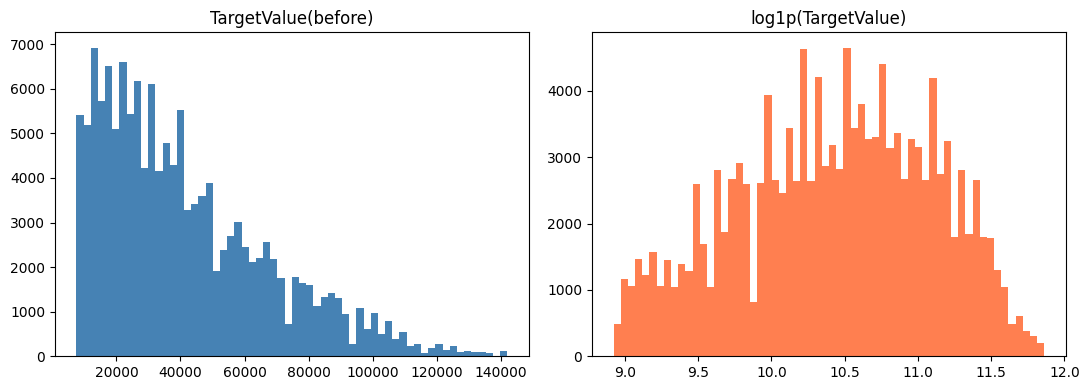

skew after log: -0.19830390386050986


In [11]:
#check target value stat
print(train_raw['TargetValue'].describe())
print("skew:", train_raw['TargetValue'].skew())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train_raw['TargetValue'], bins=60, color='steelblue')
axes[0].set_title('TargetValue(before)')

log_target = np.log1p(train_raw['TargetValue'])
axes[1].hist(log_target, bins=60, color='coral')
axes[1].set_title('log1p(TargetValue)')
plt.tight_layout()
plt.show()

print("skew after log:", log_target.skew())
#usin log1p coz target val is right skew

Cols with relations to price for now
1. eq cat
2. hrs
3. util order
4. year
5. 

In [12]:
#manufacture year check and correct

print(train_raw['ManufactureYear'].describe())

#rows below 1900
print((train_raw['ManufactureYear'] < 1900).sum())

count    138701.000000
mean       1891.640853
std         306.992001
min        1001.000000
25%        1990.000000
50%        1998.000000
75%        2004.000000
max        2015.000000
Name: ManufactureYear, dtype: float64
14719


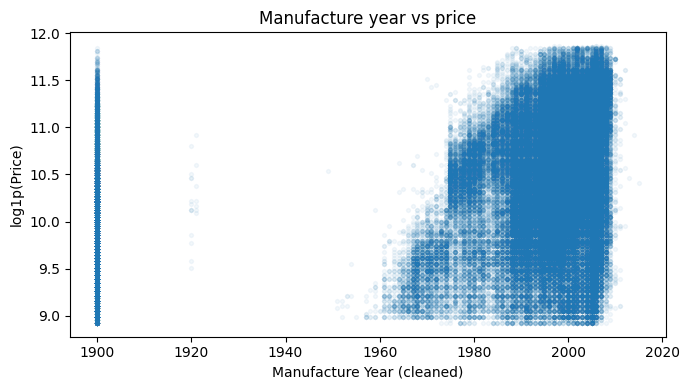

In [13]:
#clip anythin below 1900 and keep rest

train_raw['ManufactureYear_clean'] = train_raw['ManufactureYear'].clip(1900, 2016)

plt.figure(figsize=(7, 4))
plt.scatter(train_raw['ManufactureYear_clean'], np.log1p(train_raw['TargetValue']), alpha=0.05, s=8)
plt.xlabel('Manufacture Year (cleaned)')
plt.ylabel('log1p(Price)')
plt.title('Manufacture year vs price')
plt.tight_layout()
plt.show()

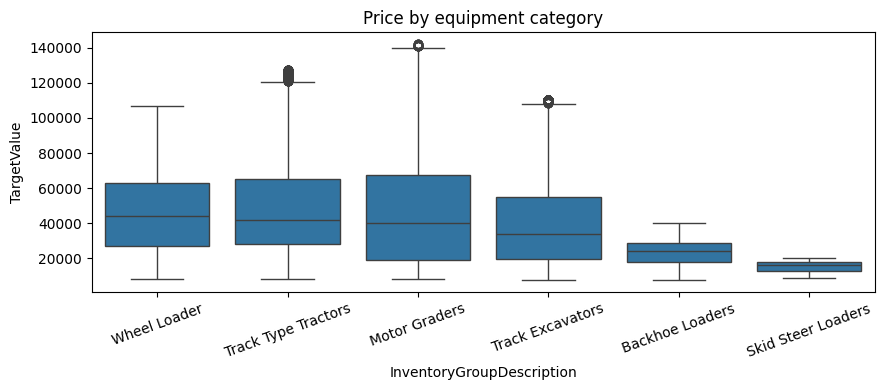

In [14]:
#eq category by price rel. 
cat_order = train_raw.groupby('InventoryGroupDescription')['TargetValue'].median().sort_values(ascending=False).index

plt.figure(figsize=(9, 4))
sns.boxplot(data=train_raw, x='InventoryGroupDescription', y='TargetValue', order=cat_order)
plt.xticks(rotation=20)
plt.title('Price by equipment category')
plt.tight_layout()
plt.show()

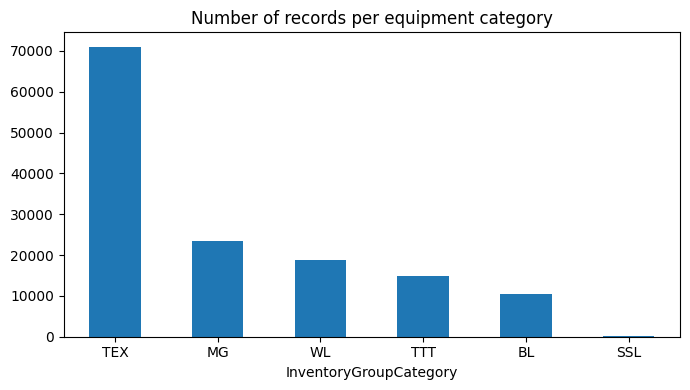

In [15]:
plt.figure(figsize=(7, 4))
train_raw['InventoryGroupCategory'].value_counts().plot(kind='bar')
plt.title('Number of records per equipment category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

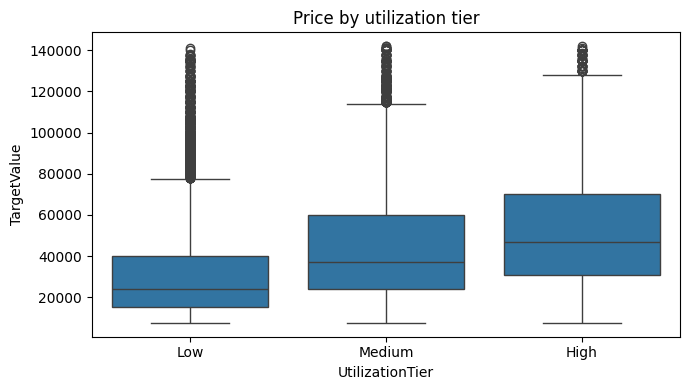

In [16]:
util_order = ['Low', 'Medium', 'High']
util_data = train_raw[train_raw['UtilizationTier'].isin(util_order)]

plt.figure(figsize=(7, 4))
sns.boxplot(data=util_data, x='UtilizationTier', y='TargetValue', order=util_order)
plt.title('Price by utilization tier')
plt.tight_layout()
plt.show()

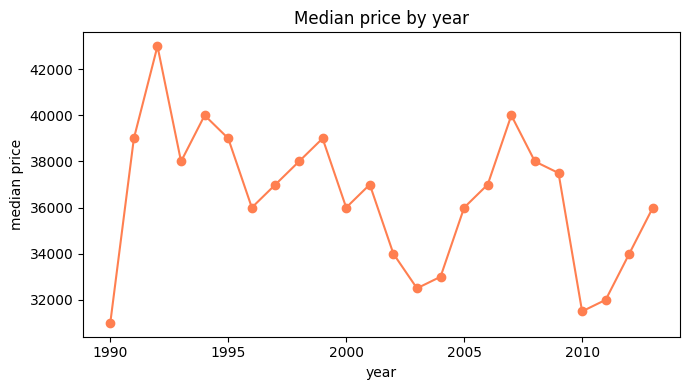

In [17]:
tx_year = pd.to_datetime(train_raw['TransactionDate'], errors='coerce').dt.year
yearly = train_raw.groupby(tx_year)['TargetValue'].median()

plt.figure(figsize=(7, 4))
plt.plot(yearly.index, yearly.values, marker='o', color='coral')
plt.xlabel('year')
plt.ylabel('median price')
plt.title('Median price by year')
plt.tight_layout()
plt.show()

# Feature engineering

In [18]:
print(train_raw.shape)

(138701, 51)


In [19]:
#transaction_date - format correct
#sale year create
#M_year delete before 1900
#machine age create - saleyear - manu_year
# add more cols for date and age and op hours


def f_engineer(df):
    df = df.copy()

    # --- dates: extract ALL date features before dropping ---
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')
    df['sale_year']    = df['TransactionDate'].dt.year
    df['sale_month']   = df['TransactionDate'].dt.month
    df['sale_quarter'] = df['TransactionDate'].dt.quarter
    df = df.drop(columns=['TransactionDate'])

    # --- manufacture year ---
    df['ManufactureYear'] = df['ManufactureYear'].clip(1900, 2016)
    df['machine_age']     = (df['sale_year'] - df['ManufactureYear']).clip(0, 100)
    df['machine_age_sq']  = df['machine_age'] ** 2

    # --- operational hours: flag BEFORE filling ---
    df['hours_missing']         = df['OperationalHoursMeter'].isnull().astype(int)
    df['OperationalHoursMeter'] = df['OperationalHoursMeter'].fillna(0)
    df['log_hours']             = np.log1p(df['OperationalHoursMeter'])
    df['hours_per_year']        = df['OperationalHoursMeter'] / df['machine_age'].replace(0, 1)

    # --- interaction feature ---
    df['age_x_loghours'] = df['machine_age'] * df['log_hours']

    # --- spec features: before label encoding loop ---
    df['spec_num'] = df['Spec_FullDescriptor'].str.extract(r'(\d+)')[0].astype(float)
    df['log_spec_base'] = np.log1p(
        pd.to_numeric(df['Spec_BaseClass'], errors='coerce').fillna(0)
    )

    # --- missing flags: before label encoding loop ---
    df['util_missing']       = df['UtilizationTier'].isnull().astype(int)
    df['drivetrain_missing'] = df['DrivetrainType'].isnull().astype(int)

    # --- utilization ordinal ---
    util_map = {'Low': 0, 'Medium': 1, 'High': 2}
    df['utilization_score'] = df['UtilizationTier'].map(util_map).fillna(-1)

    # --- label encode all remaining text columns ---
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].fillna('missing').astype('category').cat.codes

    return df

combined    = pd.concat([train_raw, test_raw], ignore_index=True)
combined_fe = f_engineer(combined)
train_fe    = combined_fe.iloc[:len(train_raw)].copy()
test_fe     = combined_fe.iloc[len(train_raw):].copy()
print(train_fe.shape)
print(test_fe.shape)

#transaction_date - format correct
#sale year create
#M_year delete begffore 1900
#machine age create - saleyear - manu_year



# def f_engineer(df):
#     df = df.copy()

#     df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')
#     df['sale_year'] = df['TransactionDate'].dt.year
#     df['sale_month'] = df['TransactionDate'].dt.month
#     df = df.drop(columns=['TransactionDate'])

#     # fix bad manufac years
#     df['ManufactureYear'] = df['ManufactureYear'].clip(1900, 2016)
#     df['machine_age'] = (df['sale_year'] - df['ManufactureYear']).clip(0, 100)

#     # op hours flag missing instead of just filling blindly
#     df['hours_missing'] = df['OperationalHoursMeter'].isnull().astype(int)
#     df['OperationalHoursMeter'] = df['OperationalHoursMeter'].fillna(0)
#     df['log_hours'] = np.log1p(df['OperationalHoursMeter'])
#     df['hours_per_year'] = df['OperationalHoursMeter'] / df['machine_age'].replace(0, 1)

#     # spec base class... convert to num  this time
#     df['log_spec_base'] = np.log1p(pd.to_numeric(df['Spec_BaseClass'], errors='coerce').fillna(0))

#     util_map = {'Low': 0, 'Medium': 1, 'High': 2}
#     df['utilization_score'] = df['UtilizationTier'].map(util_map).fillna(-1)

#     for col in ['UtilizationTier', 'Spec_ReleaseSeries', 'AssetScaleFactor', 'DrivetrainType']:
#         if col in df.columns:
#             df[col + '_missing'] = df[col].isnull().astype(int)

#     for col in df.select_dtypes(include='object').columns:
#         if col == "Spec_BaseClass":
#             df[col] = df[col].fillna("missing")
#         else:
#             df[col] = (df[col].fillna("missing").astype("category").cat.codes)

#     return df

# combined = pd.concat([train_raw, test_raw], ignore_index=True)
# combined_fe = f_engineer(combined)


# train_fe = combined_fe.iloc[:len(train_raw)].copy()
# test_fe  = combined_fe.iloc[len(train_raw):].copy()

# print(train_fe.shape)
# print(test_fe.shape)

#so here we gain additional columns 11

(138701, 64)
(15000, 64)


In [20]:
 
# Target encoding
tenc_cols = [
    'Spec_FullDescriptor',
    'FunctionalClassification',
    'InventoryGroupDescription',
    'RegionCode',
    'VendorPartnerID'
]
# log target for computing means
log_target = np.log1p(train_raw['TargetValue'])
global_mean = log_target.mean()
smoothing = 20
tenc_maps = {}
for col in tenc_cols:
    if col not in train_fe.columns:
        print(f"skipping {col} - not in train_fe")
        continue
    # get the label-encoded version of this column from train_fe
    encoded_col = train_fe[col]
    # group log-price by the encoded values
    stats = log_target.groupby(encoded_col).agg(['mean', 'count'])
    # smoothed mean: rare categories pulled toward global mean
    # formula: (count * category_mean + k * global_mean) / (count + k)
    stats['smoothed'] = (
        (stats['mean'] * stats['count'] + global_mean * smoothing)
        / (stats['count'] + smoothing)
    )
    # save map for applying to test later
    tenc_maps[col] = {
        'map': stats['smoothed'].to_dict(),
        'global_mean': global_mean
    }
    # add new column to train_fe
    new_col_name = col + '_tenc'
    train_fe[new_col_name] = encoded_col.map(stats['smoothed']).fillna(global_mean)
    print(f"added {new_col_name}")
# apply same maps to test_fe
for col in tenc_cols:
    if col not in tenc_maps:
        continue
    if col not in test_fe.columns:
        continue
    new_col_name = col + '_tenc'
    test_fe[new_col_name] = test_fe[col].map(
        tenc_maps[col]['map']
    ).fillna(tenc_maps[col]['global_mean'])
    print(f"applied {new_col_name} to test_fe")
print("\ntrain_fe shape:", train_fe.shape)
print("test_fe shape :", test_fe.shape)
print("new tenc columns:", [c for c in train_fe.columns if '_tenc' in c])

added Spec_FullDescriptor_tenc
added FunctionalClassification_tenc
added InventoryGroupDescription_tenc
added RegionCode_tenc
added VendorPartnerID_tenc
applied Spec_FullDescriptor_tenc to test_fe
applied FunctionalClassification_tenc to test_fe
applied InventoryGroupDescription_tenc to test_fe
applied RegionCode_tenc to test_fe
applied VendorPartnerID_tenc to test_fe

train_fe shape: (138701, 69)
test_fe shape : (15000, 69)
new tenc columns: ['Spec_FullDescriptor_tenc', 'FunctionalClassification_tenc', 'InventoryGroupDescription_tenc', 'RegionCode_tenc', 'VendorPartnerID_tenc']


# Split here


In [21]:
# #split em
# drop_cols = ['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID']
# feature_cols = [c for c in train_fe.columns if c not in drop_cols]

# x = train_fe[feature_cols].fillna(-99)
# y = np.log1p(train_fe['TargetValue'])
# x_train, x_test, y_train, y_test = train_test_split(
#     x, y, test_size=0.2, random_state=SEED
# )
# print(x_train.shape, x_test.shape)

#next simple imp to try 
drop_cols = ['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID']
feature_cols = [c for c in train_fe.columns if c not in drop_cols]

x = train_fe[feature_cols].copy()
y = np.log1p(train_fe["TargetValue"])

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=SEED
)

# impute - fit on train only, apply same to val and test
from sklearn.impute import SimpleImputer
num_cols = x_train.select_dtypes(include=["number"]).columns

imp = SimpleImputer(strategy="median")
x_train[num_cols] = imp.fit_transform(x_train[num_cols])
x_test[num_cols]  = imp.transform(x_test[num_cols])

# for test_fe, select same feature_cols first then impute
X_test_final = test_fe[feature_cols].copy()
X_test_final[num_cols] = imp.transform(X_test_final[num_cols])

print(x_train.shape, x_test.shape)
print(X_test_final.shape)

(110960, 65) (27741, 65)
(15000, 65)


In [22]:
#def rmsle(y_true, y_pred):
   # return np.sqrt(np.mean((y_pred - y_true) ** 2))


# Model build here

## train other models now. list them properly for god sake

both are doing bad but they are standard ones so les focus on forest models

In [23]:
#ridge and lasoo first
scaler = StandardScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)

#ridge
ridge = Ridge(alpha=10, random_state=SEED)
ridge.fit(x_train_scale, y_train)
ridge_pred = ridge.predict(x_test_scale)
print("Ridge rmsle ", rmsle(y_test.values, ridge_pred))

#tedlasso
lasso = Lasso(alpha=0.001, random_state=SEED)
lasso.fit(x_train_scale, y_train)
lasso_pred = lasso.predict(x_test_scale)
print("lasso rmsle ", rmsle(y_test.values, lasso_pred))

#best score
# Ridge rmsle  0.0275808424372435
# lasso rmsle  0.027679826988087016

Ridge rmsle  0.027581020495276793
lasso rmsle  0.027679779320717735


In [24]:
# #forest models
# rf = RandomForestRegressor(
#     n_estimators=600,
#     max_features=0.6,
#     oob_score=True,
#     random_state=SEED,
#     n_jobs=-1
# )

# rf.fit(x_train, y_train)
# rf_pred = rf.predict(x_test)
# print("RF rmsle ", rmsle(y_test.values, rf_pred))

# et = ExtraTreesRegressor(
#     n_estimators=800,
#     max_features=0.8,
#     random_state=SEED,
#     n_jobs=-1
# )

# et.fit(x_train, y_train)
# et_pred = et.predict(x_test)
# print("et rmsle ", rmsle(y_test.values, et_pred))

# #gb
# gbr = GradientBoostingRegressor(
#     n_estimators=1500,
#     learning_rate=0.02,
#     max_depth=4,
#     min_samples_leaf=2,
#     subsample=0.85,
#     max_features=0.7,
#     n_iter_no_change=20,
#     random_state=SEED
# )
# gbr.fit(x_train, y_train)
# gb_pred = gbr.predict(x_test)
# print("GBR rmsle", rmsle(y_test.values, gb_pred))

In [25]:
# forest models
# rf = RandomForestRegressor(
#     n_estimators=400,
#     max_features=0.6,
#     oob_score=True,
#     random_state=SEED,
#     n_jobs=-1
# )
# print("Starting forest fit")
# rf.fit(x_train, y_train)
# print("Finished rf fit")
# rf_pred = rf.predict(x_test)
# print("Prediction done")
# print("GBR rmsle", rmsle(y_test.values, rf_pred))

In [26]:
# et = ExtraTreesRegressor(
#     n_estimators=800,
#     max_features=0.8,
#     random_state=SEED,
#     n_jobs=-1
# )
# print("Starting et fit")
# et.fit(x_train, y_train)
# print("Finished et fit")
# et_pred = et.predict(x_test)
# print("Prediction done")
# print("et rmsle ", rmsle(y_test.values, et_pred))

# #gb
# gbr = GradientBoostingRegressor(
#     n_estimators=1500,
#     learning_rate=0.02,
#     max_depth=4,
#     min_samples_leaf=2,
#     subsample=0.85,
#     max_features=0.7,
#     n_iter_no_change=20,
#     random_state=SEED
# )
# print("Starting gbr fit")
# gbr.fit(x_train, y_train)
# print("Finished gbr fit")
# gb_pred = gbr.predict(x_test)
# print("Prediction done")
# print("GBR rmsle", rmsle(y_test.values, gb_pred))

In [27]:
#boosting models here
xgb_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.025,
    max_depth=7,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    random_state=SEED,
    verbosity=0,
    
    tree_method="hist",
    device="cuda",
)
print("Starting xgb fit")
xgb_model.fit(x_train, y_train)
print("Finished xgb fit")
xgb_pred = xgb_model.predict(x_test)
print("Prediction done")
print("XBG rmsle", rmsle(y_test.values, xgb_pred))

lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_lambda=1,
    random_state=SEED,
    verbose=-1,

    device="gpu",
)
print("Starting lbg fit")
lgb_model.fit(x_train, y_train)
print("Finished lgb fit")
lgb_pred = lgb_model.predict(x_test)
print("Prediction done")
print("LIght rmsle", rmsle(y_test.values, lgb_pred))

Starting xgb fit
Finished xgb fit
Prediction done
XBG rmsle 0.018327457035802536
Starting lbg fit


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Finished lgb fit
Prediction done
LIght rmsle 0.01844052747385411


In [28]:
#catboost 

cat_model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.03,
    depth=10,
    l2_leaf_reg=5,
    random_strength=1.5,
    bagging_temperature=0.8,
    border_count=254,
    bootstrap_type="Bayesian",
    grow_policy="SymmetricTree",
    loss_function="RMSE",
    eval_metric="RMSE",
    task_type="GPU",
    devices="0",
    verbose=200
)

print("Starting CatBoost fit")

cat_model.fit(x_train, y_train)

print("Finished CatBoost fit")

cat_pred = cat_model.predict(x_test)

print("Prediction done")

print("CatBoost RMSLE:", rmsle(y_test.values, cat_pred))

Starting CatBoost fit
0:	learn: 0.6558990	total: 244ms	remaining: 20m 20s
200:	learn: 0.2406049	total: 2.15s	remaining: 51.4s
400:	learn: 0.2223269	total: 3.9s	remaining: 44.7s
600:	learn: 0.2110552	total: 5.64s	remaining: 41.3s
800:	learn: 0.2030522	total: 7.39s	remaining: 38.7s
1000:	learn: 0.1969247	total: 9.17s	remaining: 36.6s
1200:	learn: 0.1914189	total: 11s	remaining: 34.6s
1400:	learn: 0.1868074	total: 12.7s	remaining: 32.6s
1600:	learn: 0.1826499	total: 14.4s	remaining: 30.7s
1800:	learn: 0.1787122	total: 16.2s	remaining: 28.8s
2000:	learn: 0.1751707	total: 18s	remaining: 27s
2200:	learn: 0.1719403	total: 19.8s	remaining: 25.2s
2400:	learn: 0.1687397	total: 21.6s	remaining: 23.4s
2600:	learn: 0.1657778	total: 23.4s	remaining: 21.6s
2800:	learn: 0.1628070	total: 25.2s	remaining: 19.8s
3000:	learn: 0.1600374	total: 27s	remaining: 18s
3200:	learn: 0.1574501	total: 28.8s	remaining: 16.2s
3400:	learn: 0.1549556	total: 30.6s	remaining: 14.4s
3600:	learn: 0.1525436	total: 32.4s	rema

In [29]:
# cal all scores

results = pd.DataFrame({
    #'model': ['Ridge', 'Lasso', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'XGBoost', 'LightGBM'],
    'model': ['Ridge', 'Lasso', 'XGBoost', 'LightGBM', 'Catboost'],
    'test_rmsle': [
        rmsle(y_test.values, ridge_pred),
        rmsle(y_test.values, lasso_pred),
        #rmsle(y_test.values, rf_pred),
        #rmsle(y_test.values, et_pred),
        #rmsle(y_test.values, gb_pred),
        rmsle(y_test.values, xgb_pred),
        rmsle(y_test.values, lgb_pred),
        rmsle(y_test.values, cat_pred)
    ]
}).sort_values('test_rmsle')
results

#

# model	test_rmsle
# 2	XGBoost	0.018318
# 3	LightGBM	0.018462
# 0	Ridge	0.027581
# 1	Lasso	0.027680


,model,test_rmsle
4,Catboost,0.017638
2,XGBoost,0.018327
3,LightGBM,0.018441
0,Ridge,0.027581
1,Lasso,0.027680


# Tuning part

In [30]:
# random forest tuning

# param_grid = {
#     'n_estimators': [400, 500, 600, 700, 800],
#     'max_features': [0.4, 0.5, 0.6, 0.7, 0.8],
#     'max_depth': [None, 20, 30, 40],
#     'min_samples_split': [2, 3, 5, 8],
#     'min_samples_leaf': [1, 2, 3],
#     'bootstrap': [True],
#     'oob_score': [True]
# }

# print("starting random forest search...")

# search = RandomizedSearchCV(
#     RandomForestRegressor(
#         random_state=SEED,
#         n_jobs=-1
#     ),
#     param_distributions=param_grid,
#     n_iter=20,
#     cv=3,
#     scoring=neg_rmsle,
#     random_state=SEED,
#     n_jobs=1,
#     verbose=1
# )

# print("fitting random forest...")

# search.fit(x_train, y_train)

# print("search complete")

# print("best params:", search.best_params_)
# print("best cv score:", -search.best_score_)

# best_rf = search.best_estimator_

# print("making predictions...")

# rf_tuned_pred = best_rf.predict(x_test)

# print("done")
# print("tuned rf rmsle:", rmsle(y_test.values, rf_tuned_pred))

In [31]:
#catboost tuning

param_grid = {
    'iterations': [4000, 5000, 6000],
    'learning_rate': [0.02, 0.025, 0.03],
    'depth': [6, 7, 8, 9],
    'l2_leaf_reg': [5, 8, 12, 15],
    'random_strength': [1, 2, 3],
    'bagging_temperature': [0.8, 1.0, 1.5],
    'border_count': [128, 192, 254],
    'grow_policy': ['SymmetricTree'],
    'min_data_in_leaf': [5, 10, 15]
}


print("Starting CatBoost Search...")

search = RandomizedSearchCV(
    CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        bootstrap_type="Bayesian",
        task_type="GPU",
        devices="0:1",
        random_seed=SEED,
        verbose=0,
        early_stopping_rounds=150
    ),
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring=neg_rmsle,
    random_state=SEED,
    n_jobs=1,
    verbose=2
)

print("Fitting CatBoost...")

search.fit(x_train, y_train)

print("\nSearch Complete")

print("Best Parameters:")
print(search.best_params_)

print("\nBest CV RMSLE:")
print(-search.best_score_)

best_cat = search.best_estimator_

print("\nMaking Predictions...")

cat_tuned_pred = best_cat.predict(x_test)

print("Done")

print("Validation RMSLE:",
      rmsle(y_test.values, cat_tuned_pred))

Starting CatBoost Search...
Fitting CatBoost...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END bagging_temperature=1.0, border_count=254, depth=8, grow_policy=SymmetricTree, iterations=5000, l2_leaf_reg=8, learning_rate=0.02, min_data_in_leaf=15, random_strength=2; total time=  50.4s
[CV] END bagging_temperature=1.0, border_count=254, depth=8, grow_policy=SymmetricTree, iterations=5000, l2_leaf_reg=8, learning_rate=0.02, min_data_in_leaf=15, random_strength=2; total time=  50.8s
[CV] END bagging_temperature=1.0, border_count=254, depth=8, grow_policy=SymmetricTree, iterations=5000, l2_leaf_reg=8, learning_rate=0.02, min_data_in_leaf=15, random_strength=2; total time=  50.0s
[CV] END bagging_temperature=0.8, border_count=128, depth=8, grow_policy=SymmetricTree, iterations=5000, l2_leaf_reg=15, learning_rate=0.03, min_data_in_leaf=10, random_strength=3; total time=  52.6s
[CV] END bagging_temperature=0.8, border_count=128, depth=8, grow_policy=SymmetricTree, iterat

In [32]:
# # xgboost tuning

param_grid = {
    'n_estimators': [1000, 1200, 1500, 1800],
    'learning_rate': [0.02, 0.025, 0.03, 0.04],
    'max_depth': [5, 6, 7, 8],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.8, 0.85, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0.5, 1, 2]
}

print("starting xgboost search...")

search = RandomizedSearchCV(
    XGBRegressor(
        random_state=SEED,
        verbosity=0,
        tree_method='hist',
        device="cuda"
    ),
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring=neg_rmsle,
    random_state=SEED,
    n_jobs=1,
    verbose=1,
)

print("fitting xgboost...")

search.fit(x_train, y_train)

print("search complete")

print("best params:", search.best_params_)
print("best cv score:", -search.best_score_)

best_xgb = search.best_estimator_

print("making predictions...")

xgb_tuned_pred = best_xgb.predict(x_test)

print("done")
print("tuned xgboost rmsle:", rmsle(y_test.values, xgb_tuned_pred))

starting xgboost search...
fitting xgboost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
search complete
best params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.04, 'gamma': 0, 'colsample_bytree': 0.9}
best cv score: 0.018311053593383243
making predictions...
done
tuned xgboost rmsle: 0.017775672025241517


In [33]:
# # lightgbm 

param_grid = {
    'n_estimators': [1000, 1200, 1500, 1800],
    'learning_rate': [0.02, 0.025, 0.03, 0.04],
    'num_leaves': [50, 64, 80, 100],
    'min_child_samples': [15, 20, 30],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'subsample': [0.8, 0.85, 0.9]
}

print("starting lightgbm search...")

search = RandomizedSearchCV(
    LGBMRegressor(
        random_state=SEED,
        verbose=-1,
        device='gpu',
    ),
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring=neg_rmsle,
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

print("fitting lightgbm...")

search.fit(x_train, y_train)

print("search complete")

print("best params:", search.best_params_)
print("best cv score:", -search.best_score_)

best_lgb = search.best_estimator_

print("making predictions...")

lgb_tuned_pred = best_lgb.predict(x_test)

print("done")
print("tuned lightgbm rmsle:", rmsle(y_test.values, lgb_tuned_pred))

starting lightgbm search...
fitting lightgbm...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
search complete
best params: {'subsample': 0.9, 'num_leaves': 80, 'n_estimators': 1800, 'min_child_samples': 15, 'learning_rate': 0.025, 'colsample_bytree': 0.8}
best cv score: 0.018510894538308915
making predictions...
done
tuned lightgbm rmsle: 0.018055551911780734


In [34]:
# print("random forest")
# rf_train_pred = best_rf.predict(x_train)
# print("train rmsle:", rmsle(y_train.values, rf_train_pred))
# print("val rmsle:", rmsle(y_test.values, rf_tuned_pred))

# print("xgboost")
# xgb_train_pred = best_xgb.predict(x_train)
# print("train rmsle:", rmsle(y_train.values, xgb_train_pred))
# print("val rmsle:", rmsle(y_test.values, xgb_tuned_pred))

# print("lightgbm")
# lgb_train_pred = best_lgb.predict(x_train)
# print("train rmsle:", rmsle(y_train.values, lgb_train_pred))
# print("val rmsle:", rmsle(y_test.values, lgb_tuned_pred))

# cal sccore

In [35]:
# score calc

print("catboost")
cat_train_pred = best_cat.predict(x_train)
cat_test_pred = best_cat.predict(x_test)

train_score = rmsle(y_train.values, cat_train_pred)
test_score = rmsle(y_test.values, cat_test_pred)

print("Train RMSLE:", train_score)
print("TEst RMSLE:", test_score)


print("xgboost")
xgb_train_pred = best_xgb.predict(x_train)
xgb_test_pred = best_xgb.predict(x_test)

train_score = rmsle(y_train.values, xgb_train_pred)
test_score = rmsle(y_test.values, xgb_test_pred)

print("Train RMSLE:", train_score)
print("TEst RMSLE:", test_score)

print()

print("lightgbm")
lgb_train_pred = best_lgb.predict(x_train)
lgb_test_pred = best_lgb.predict(x_test)

train_score = rmsle(y_train.values, lgb_train_pred)
test_score = rmsle(y_test.values, lgb_test_pred)

print("Train RMSLE:", train_score)
print("Test RMSLE:", test_score)

catboost
Train RMSLE: 0.014413462053501278
TEst RMSLE: 0.017955550847817546
xgboost
Train RMSLE: 0.013534994012398471
TEst RMSLE: 0.017775672025241517

lightgbm
Train RMSLE: 0.015038976300248901
Test RMSLE: 0.018055551911780734


# submit it

In [36]:
test_df = test_fe.copy()

print("test_df shape:", test_df.shape)
# if i feature engineer seperatel they both get asssigned different values - coz i am using label encoder

test_df shape: (15000, 69)


In [37]:
# CatBoost only

cat_final = best_cat.predict(X_test_final)

print("CatBoost predictions donuh.")

CatBoost predictions donuh.


In [38]:
# find best weights for XGBoost + LightGBM + CatBoost

best_score = float("inf")
best_weights = None

for w_xgb in np.arange(0.10, 0.91, 0.05):
    for w_lgb in np.arange(0.10, 0.91, 0.05):

        w_cat = 1.0 - w_xgb - w_lgb
        if w_cat < 0.10:
            continue
        pred = (
            w_xgb * xgb_test_pred +
            w_lgb * lgb_test_pred +
            w_cat * cat_test_pred
        )

        score = rmsle(y_test.values, pred)

        print(
            f"XGB={w_xgb:.2f}, "
            f"LGB={w_lgb:.2f}, "
            f"CAT={w_cat:.2f} "
            f"-> RMSLE={score:.6f}"
        )
        
        if score < best_score:
            best_score = score
            best_weights = (w_xgb, w_lgb, w_cat)

print("\nBest Weights:")
print(f"XGB = {best_weights[0]:.2f}")
print(f"LGB = {best_weights[1]:.2f}")
print(f"CAT = {best_weights[2]:.2f}")
print(f"Best RMSLE = {best_score:.6f}")

XGB=0.10, LGB=0.10, CAT=0.80 -> RMSLE=0.017864
XGB=0.10, LGB=0.15, CAT=0.75 -> RMSLE=0.017853
XGB=0.10, LGB=0.20, CAT=0.70 -> RMSLE=0.017844
XGB=0.10, LGB=0.25, CAT=0.65 -> RMSLE=0.017838
XGB=0.10, LGB=0.30, CAT=0.60 -> RMSLE=0.017835
XGB=0.10, LGB=0.35, CAT=0.55 -> RMSLE=0.017834
XGB=0.10, LGB=0.40, CAT=0.50 -> RMSLE=0.017835
XGB=0.10, LGB=0.45, CAT=0.45 -> RMSLE=0.017840
XGB=0.10, LGB=0.50, CAT=0.40 -> RMSLE=0.017846
XGB=0.10, LGB=0.55, CAT=0.35 -> RMSLE=0.017856
XGB=0.10, LGB=0.60, CAT=0.30 -> RMSLE=0.017868
XGB=0.10, LGB=0.65, CAT=0.25 -> RMSLE=0.017883
XGB=0.10, LGB=0.70, CAT=0.20 -> RMSLE=0.017900
XGB=0.10, LGB=0.75, CAT=0.15 -> RMSLE=0.017920
XGB=0.15, LGB=0.10, CAT=0.75 -> RMSLE=0.017841
XGB=0.15, LGB=0.15, CAT=0.70 -> RMSLE=0.017831
XGB=0.15, LGB=0.20, CAT=0.65 -> RMSLE=0.017824
XGB=0.15, LGB=0.25, CAT=0.60 -> RMSLE=0.017819
XGB=0.15, LGB=0.30, CAT=0.55 -> RMSLE=0.017817
XGB=0.15, LGB=0.35, CAT=0.50 -> RMSLE=0.017818
XGB=0.15, LGB=0.40, CAT=0.45 -> RMSLE=0.017821
XGB=0.15, LGB

In [39]:
# #more ensmeble 
# ensemble_pred = (0.8 * xgb_test_pred + 0.2 * lgb_test_pred)
# ensemble_score = rmsle(y_test.values, ensemble_pred)

# print("Weighted Ensemble RMSLE:", ensemble_score)

In [40]:
# summa submission file
#catboost mattum


final_predictions = np.expm1(cat_final)
final_predictions = np.clip(final_predictions, 0, None)

submission = pd.DataFrame({
    'TransactionID': test_raw['TransactionID'],
    'TargetValue': final_predictions
})

submission.to_csv('submission.csv', index=False)

print("Submission file created successfully!")
print(f"Shape: {submission.shape}")
print(submission.head(10))
print("\nMin/Max predictions:", final_predictions.min(), final_predictions.max())

Submission file created successfully!
Shape: (15000, 2)
   TransactionID   TargetValue
0        1139307  60647.659762
1        1139419  79703.931752
2        1139482  27635.360995
3        1139522  19169.414611
4        1139684  11077.174107
5        1139773  29315.539606
6        1139779  20195.523617
7        1139793  43183.197414
8        1139814  72561.378764
9        1139839  15984.619369

Min/Max predictions: 7186.229977037453 141094.43121804987


In [41]:
# #submit 
# #log should be taken back
# #

# X_test_final = test_df[feature_cols].fillna(-99)

# xgb_final = best_xgb.predict(X_test_final)
# lgb_final = best_lgb.predict(X_test_final)
# log_predictions = 0.9 * xgb_final + 0.1 * lgb_final

# final_predictions = np.expm1(log_predictions)
# final_predictions = np.clip(final_predictions, 0, None)  # make sure no negative prices

# submission = pd.DataFrame({
#     'TransactionID': test_raw['TransactionID'],
#     'TargetValue': final_predictions
# })

# submission.to_csv('submission.csv', index=False)

# print("Submission file created successfully!")
# print(f"Shape: {submission.shape}")
# print(submission.head(10))
# print("\nMin/Max predictions:", final_predictions.min(), final_predictions.max())

In [42]:
#MIlestone-1
#Q1
#print('Train shape:', train_raw.shape)

#Q2


#Q3
#n = train_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
#print(n)

#Q4 and Q5
#miss_pt = (train_raw.isnull().sum()/ len(train_raw) *100).sort_values(ascending=False)
#print(miss_pt)

#Q6
#m = train_raw["TargetValue"].median()
#print(m)

#Q7
#print(train_raw["ManufactureYear"].mode()[0])

#Q8
#print(train_raw["TransactionDate"].min())

#Q9)
#print(train_raw["Spec_BaseClass"].nunique())

#Q10
#a = train_raw["RegionCode"].value_counts()
#print(a)

#Q11
#av= train_raw[train_raw['RegionCode'] == 'Florida']['TargetValue'].mean()
#print(av)
#45007.54

#Q12
#u = train_raw["UtilizationTier"].value_counts()
#print(u)
#medium

#Q13
#cr = train_raw["TargetValue"].corr(train_raw["OperationalHoursMeter"])
#print(cr)

#Q14
#c= train_raw["FunctionalClassification"].mode()
#print(c)

In [43]:
#Milestone-2
#make the necessary variables first
#from sklearn.linear_model import LinearRegression
#from sklearn.metrics import r2_score
#
#train_raw["TransactionDate"] = pd.to_datetime(train_raw["TransactionDate"])
#train_raw["TransactionYear"] = train_raw["TransactionDate"].dt.year

#train_raw["TransactionQuarter"] = train_raw["TransactionDate"].dt.quarter

#train_raw["AssetAge"] = train_raw["TransactionYear"] - train_raw["ManufactureYear"]

#train_raw["DescriptorLength"] = train_raw["Spec_FullDescriptor"].fillna("").str.len()


#train_raw["HasVariantModifier"] = train_raw["Spec_VariantModifier"].notna().astype(int)

#train_raw["HasOperationalHours"] = train_raw["OperationalHoursMeter"].notna().astype(int)


#train_raw["HasVariantModifier"] = train_raw["Spec_VariantModifier"].notna().astype(int)


#encoded = pd.get_dummies(train_raw, columns=["RegionCode", "CabinType", "UtilizationTier"], drop_first=True)


##from sklearn.impute import SimpleImputer
#num_cols = ["ManufactureYear", "OperationalHoursMeter", "AssetAge"]
#imputer = SimpleImputer(strategy="mean")

#train_raw[num_cols] = imputer.fit_transform(train_raw[num_cols])
#scaler = StandardScaler()
#train_raw[num_cols] = scaler.fit_transform(train_raw[num_cols])
#processed = pd.get_dummies(train_raw, columns=["RegionCode", "CabinType", "UtilizationTier"], drop_first=True)

#x = processed.drop("TargetValue", axis=1)
#y = processed["TargetValue"]



#x = train_raw[["ManufactureYear", "AssetAge"]]
#y = train_raw["TargetValue"]
#x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=4 )
#model = LinearRegression()
#model.fit(x_train, y_train)

#pred = model.predict(x_test)

#q1
#train_raw["AssetAge"].value_counts()

#q2
#train_raw.groupby("TransactionQuarter")["TargetValue"].mean()

#q3
#train_raw["DescriptorLength"].max()

#q4
#train_raw["HasOperationalHours"].sum()

#q5
#percentage = train_raw["HasVariantModifier"].mean()*100
#print(percentage)

#q6
#round(train_raw["ManufactureYear"].mean(),2)

#q7
#print("old cols:", train_raw.shape[1])
#print("after encoding:", encoded.shape[1])

#print("new ", encoded.shape[1] - train_raw.shape[1])

#q8
#features = ["ManufactureYear", "OperationalHoursMeter", "AssetID", "ProductConfigID"]
#corr.loc[features, "TargetValue"].abs().idxmax()

#q9 and 10
#x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
#x_train.shape
#x_test.shape

#q11

#r2 = r2_score(y_test, pred)
#print(r2)



In [44]:
# #milestone-3
# # Q1
# skew = train_raw['OperationalHoursMeter'].skew()
# mean_val = train_raw['OperationalHoursMeter'].mean()
# median_val = train_raw['OperationalHoursMeter'].median()
# print(f"Skewn: {skew:.4f}")
# print(f"Mean: {mean_val:.2f}")
# print(f"Median: {median_val:.2f}")

# Q2
# train_raw['TransactionDate'] = pd.to_datetime(train_raw['TransactionDate'], errors='coerce')
# train_raw['SaleYear'] = train_raw['TransactionDate'].dt.year

# mode_year = train_raw['SaleYear'].mode()[0]
# print(mode_year)

# Q3
# missing_pct = (train_raw.isnull().sum() / len(train_raw)) * 100
# drop_cols = missing_pct[missing_pct > 80]

# print(drop_cols)
# print(len(drop_cols))


# Q4
# cabin_missing = train_raw['CabinType'].isnull().sum()
# print(cabin_missing)

# Q5
# tmp = train_raw.copy()
# tmp['AssetAge'] = tmp['SaleYear'] - tmp['ManufactureYear']
# tmp['OperationalHoursMeter'] = tmp['OperationalHoursMeter'].fillna(tmp['OperationalHoursMeter'].median())
# tmp['HoursPerYear'] = (tmp['OperationalHoursMeter'] / tmp['AssetAge'].replace(0, np.nan))
# tmp['HoursPerYear'] = tmp['HoursPerYear'].replace([np.inf, -np.inf], np.nan)
# print(tmp['HoursPerYear'].median())

# # Q6
# tmp2 = train_raw.copy()
# tmp2['ManufactureYear'] = tmp2['ManufactureYear'].replace([1000, 1001], np.nan)
# tmp2['AssetAge'] = tmp2['SaleYear'] - tmp2['ManufactureYear']
# print(tmp2['AssetAge'].median())
